# Lezione 4: Pipeline di Apprendimento Automatico Supervisionato per Problemi di Forecasting

Nella lezione 3 abbiamo il trodotto il problema di apprendimento automatico supervisionato come il problema di aprossimare la reale relazione esistente tra un fenomeno $X$ e un suo aspetto target $Y$. Per un problema di forecasting univariato (previsione di serie temporali) fenomeno e suo aspetto target si condensano in un **processo** $\{Y_t\}_{t=0}^{T}$ in cui una prima parte, esemplificata dalle osservazioni $S_m = \{y_t\}_{t=0}^{m}$, definisce la caratterizzazione del fenomeno da studiare, la parte restante, esemplificata da $y_{m+1}, y_{m+2}, \dots, y_{T}$, definisce l'aspetto target da predire.


Il problema di forcasting che affrontiamo in questa lezione è esemplificato dal dataset OpenDengue, che raccoglie il numero di casi con cadenza settimanale, filtrato per i soli casi del Brasile. Più precisamente, fissata la durata della nostra serie temporale a $T$, la cardinalità $m$ di un ipotetico training set e l'intervallo di campionamento $t\in \mathbb{N}$ (cadenza settimanale), abbiamo:

- **Variabili (features)**: I valori passati $y_0, y_1, \dots, y_{m-1}, y_m$ della serie temporale (ossia, la storia $S_m = \{y_t\}_{t=0}^{m}$ del processo studiato). Costituiscono le realizzazioni delle features caratterizzanti il fenomeno d'interesse.
- **Target**: I valori futuri veri della serie temporale, a un passo ($y_{m+1}$) o a $K$ ($y_{m+1}, y_{m+2}, \dots, y_{m+K}$) passi in avanti. Costituiscono le realizzazioni del target da predire.

L'obiettivo è allenare un modello predittivo per serie storiche (ad esempio un modello ARMA o ARIMA) capace di predire il numero di futuri casi di Dengue, a uno ($\hat{y}_{m+1}$) o $K$ ($\hat{y}_{m+1}, \hat{y}_{m+2}, \dots, \hat{y}_{m+K}$) passi in avanti, in modo da approssimare il più fedelmente possibile i reali valori futuri della serie storica.


## 0. Modelli lineari per forcasting di serie storiche

Prima di tutto, cerchiamo di capire come la statistica inferenziale classica tratta le serie storiche da un punto di vista di stima parametrica. Al tempo presente $t\in\mathbb{N}$, l'uscita $y(t)$ di un 'filtro' (sistema lineare tempo invariante), che riceve in ingresso un segnale $x(t)$, è un'equazione alle differenze che può essere sempre scomposta in **parte a media mobile** (moving average: combinazione lineare dell'ingresso presente $x(t)$ e degli ingressi passati, $x(t-1), x(t-2),\dots,x(t-q)$, per opportuni coefficienti $b(0), b(1),\dots, b(q)$, con $b(0)=1$) e in **parte autoregressiva** (autoregressive: combinazione lineare delle uscite passate $y(t-1), y(t-2),\dots,y(t-p)$ per opportuni coefficienti $a(0), a(1), \dots, a(q)$, con $a(0)=1$):

$$y(t)=\sum_{i=1}^{p}a(i)y(t-i) + \sum_{j=0}^{q}b(j)x(t-j)$$

Per il teorema di decomposizione di Wold, una serie temporale stazionaria $S_T=\{y_t\}_{t=0}^{T}=\{y(t)\}_{t=0}^{T}$ può essere sempre decomposta in **parte deterministica** (parte che cattura la stazionarietà del processo, ossia ciò che si ripete rimane invariato nel tempo) e **parte stocastica** (parte che cattura gli aspetti casuali del processo, definita come moving average infinita su rumore bianco):

$$
y(t) = \underbrace{d(t)}_{\text{parte deterministica}} + \underbrace{\sum_{j=0}^{q}b(j)e(t-j)}_{\text{parte stocastica}}, \quad e(t)\sim \mathcal{N}(0, \sigma_{e}^{2})
$$

Un modello ARMA(p,q) (autoregressive moving average di ordini $(p,q)$) rappresenta l'intera serie temporale come uscita di un filtro che ha parte autoregressiva di ordine $p$ (che descrive la parte deterministica del processo) e parte a media mobile di ordine $q$ (che descrive la parte stocastica come combinazione lineare dell'ingresso presente $e(t)$ e dei $q$ ingressi passati $e(t-1),...,e(t-q)$):

$$
\hat{y}^{(d)}(t) = \underbrace{\sum_{i=1}^{p}a(i)y^{(d)}(t-i)}_{\text{parte autoregressiva (AR)}} + \underbrace{\sum_{j=0}^{q}b(j)e(t-j)}_{\text{parte a media mobile (MA)}}
$$

Il nostro obiettivo è stimare i parametri $b(1),\dots, b(q)$ e $a(1),\dots, a(p)$ del nostro modello ARMA in modo che il filtro così parametrizzato generi campioni futuri, in risposta a ingressi rumorosi $e(T+1),e(T+2),\dots, e(T+K)$, in grado di approssimare bene la serie storica a $K$ ($y_{T+1}, y_{T+2}, \dots, y_{T+K}$) passi.

Una serie storica descritta da un modello ARMA (e quindi trattata come processo stocastico) non è altro che l'uscita di un filtro sollecitato da un ingresso di "rumore bianco" stazionario. Affinché l'uscita di questo filtro mantenga le proprietà di un processo stazionario è necessario che il filtro che lo genera sia **stabile**. Se, nel cercare i parametri del modello ARMA, troviamo valori che non rendono il filtro stabile è necessario intervenire introducendo un filtro integratore o differenziatore di ordine $d$ preliminare al filtraggio operato da ARMA. Il risultato (compsizione di filtro integratore/differenziatore e ARMA) è un filtro ARIMA(p,d,q): filtro ARMA(p,q) con differenziazione di ordine $d$ per rimuovere la non-stazionarietà (trend) della serie. L'uscita di tale filtro è data da:

$$\hat{y}^{(d)}(t) = \sum_{i=1}^{p}a(i)y^{(d)}(t-i) + \sum_{j=0}^{q}b(j)e(t-j)$$

dove $y^{(d)}(t)$ indica la derivazione temporale di ordine $d$ della serie, valutata in $t$.

Per gestire fenomeni che presentano non solo una memoria a breve termine, ma anche una memoria a lungo termine periodica (es. stagionalità annuale di periodo $h$), si estende il filtro al modello **SARIMA(p,d,q)(P,D,Q)[h]**.

Definendo $y^*(t)$ come la serie a cui è stata applicata sia la differenziazione regolare (di ordine $d$) sia la differenziazione stagionale (di ordine $D$ a salti di ampiezza $h$), l'equazione alle differenze, che definisce la rsiposta di un modello SARIMA all'ingresso rumoroso, combina i filtri a breve termine con i filtri stagionali (caratterizzati dai coefficienti AR stagionali $A(k)$ e MA stagionali $B(l)$):

$$
\hat{y}^*(t) = \underbrace{\sum_{i=1}^{p}a(i)y^*(t-i)}_{\text{AR regolare}} + \underbrace{\sum_{k=1}^{P}A(k)y^*(t-kh)}_{\text{AR stagionale}} - \underbrace{\sum_{i=1}^{p}\sum_{k=1}^{P}a(i)A(k)y^*(t-i-kh)}_{\text{Interazione AR}} + \underbrace{\sum_{j=0}^{q}\sum_{l=0}^{Q}b(j)B(l)e(t-j-lh)}_{\text{MA (regolare, stagionale e interazione)}}
$$

*Nota:* Il termine di interazione AR viene sottratto per compensare l'effetto incrociato dell'applicazione simultanea della dipendenza dai lag vicini e dai lag stagionali, mentre la doppia sommatoria finale modella tutte le combinazioni possibili tra le innovazioni recenti e gli shock stagionali passati.


---

In [19]:
# ── Dipendenze ──────────────────────────────────────────────────────────────
import sys, pathlib

_nb_dir = pathlib.Path(".").resolve()
if str(_nb_dir) not in sys.path:
    sys.path.insert(0, str(_nb_dir))

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from itertools import product
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX

import utilities as ut

## 1. Il Dataset OpenDengue V1.3

OpenDengue è un database open-access di conteggi settimanali/mensili/annuali
di casi di dengue per tutti i Paesi endemici dal 1924 ad oggi (Clarke *et al.*, 2024,
*Scientific Data*). Il database raccoglie dati da ministeri della salute, WHO PAHO,
pubblicazioni peer-reviewed e altre fonti pubbliche.

### Struttura del National Extract

Ogni riga rappresenta un'osservazione unica per una specifica area geografica
e periodo temporale. Le colonne rilevanti sono:

| Colonna | Descrizione |
|:--------|:------------|
| `adm_0_name` | Nome del Paese (livello admin-0) |
| `calendar_start_date` / `_end_date` | Inizio/fine del periodo |
| `Year` | Anno |
| `dengue_total` | Conteggio totale dei casi (sospetti + probabili + confermati) |
| `T_res` | Risoluzione temporale (`Week`, `Month`, `Year`) |
| `S_res` | Risoluzione spaziale (`Admin0`, `Admin1`, `Admin2`) |

### Scelta del Paese di Studio

Il **Brasile** è stato scelto come caso studio principale in quanto:
- Paese con il maggior numero di casi di dengue al mondo (spesso oltre 1 milione/anno)
- Stagionalità annuale marcata: picco epidemico in febbraio–aprile (settimane 5–15),
  corrispondente alla stagione delle piogge nelle principali aree urbane del Sud-Est

Scegliamo di concentrarci sul periodo che va dal 2015 al 2023.

In [20]:
# Carica il National Extract V1.3 (CSV locale)
CSV_PATH = "./Data/National_extract_V1_3.csv"
df_raw = pd.read_csv(
    CSV_PATH,
    parse_dates=["calendar_start_date", "calendar_end_date"],
    low_memory=False,
)
print(f"Dimensioni raw: {df_raw.shape}")
print(f"Periodo:        {df_raw['calendar_start_date'].min().date()} → "
      f"{df_raw['calendar_start_date'].max().date()}")
print(f"Paesi nel db:   {df_raw['adm_0_name'].nunique()}")
print(f"\nRisoluzione temporale:")
print(df_raw["T_res"].value_counts().to_string())

Dimensioni raw: (29873, 16)
Periodo:        1924-01-20 → 2025-04-01
Paesi nel db:   129

Risoluzione temporale:
T_res
Week     23248
Year      3495
Month     3130


In [21]:
# Prepara la serie settimanale per il Brasile
df_bra_full = ut.prepare_country_weekly(df_raw, "BRAZIL")
print(f"Brasile – settimane disponibili: {len(df_bra_full)} obs")
print(f"Intervallo: {df_bra_full['date'].min().date()} → "
      f"{df_bra_full['date'].max().date()}")
print(f"Anni presenti: {sorted(df_bra_full['Year'].unique())}")
print(f"\nStatistiche descrittive di dengue_total:")
print(df_bra_full["dengue_total"].describe().round(1).to_string())

Brasile – settimane disponibili: 418 obs
Intervallo: 2015-01-04 → 2023-12-31
Anni presenti: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2021), np.int64(2022), np.int64(2023)]

Statistiche descrittive di dengue_total:
count       418.0
mean      32630.3
std       39213.8
min        2146.0
25%        7816.2
50%       15685.5
75%       38207.8
max      186718.0


---
## 2. Analisi Esplorativa dei Dati (EDA)

L'EDA per le serie storiche si articola in quattro fasi principali:

1. **Analisi univariata** – distribuzione della variabile target, outlier, lacune
2. **Analisi del profilo stagionale** – pattern intra-annuali ricorrenti, decomposizione STL (separazione di trend, stagionalità e residuo) e test di stazionarietà.
4. **Analisi di autocorrelazione** – funzioni ACF e PACF per caratterizzare
   la dipendenza temporale a breve e lungo termine

### 2.1 Analisi Esplorativa dei dati (univariata)

La serie dei casi di dengue in Brasile mostra tre caratteristiche evidenti:

- **Trend di lungo periodo**: i casi aumentano in modo sostanziale, con picchi
  storici nel 2015 e nel 2022
- **Stagionalità annuale marcata**: picco epidemico ricorrente nelle settimane 5–15
  (febbraio–aprile, stagione delle piogge nel Sud-Est)
- **Alta variabilità inter-annuale**: la magnitude del picco stagionale varia
  di un ordine di grandezza tra anni endemici

Come primo passo, visualizziamo la serie storica e analizziamo preliminarmente la distribuzione empirica dell'unica feature/target disponibile (`dengue_total`): 

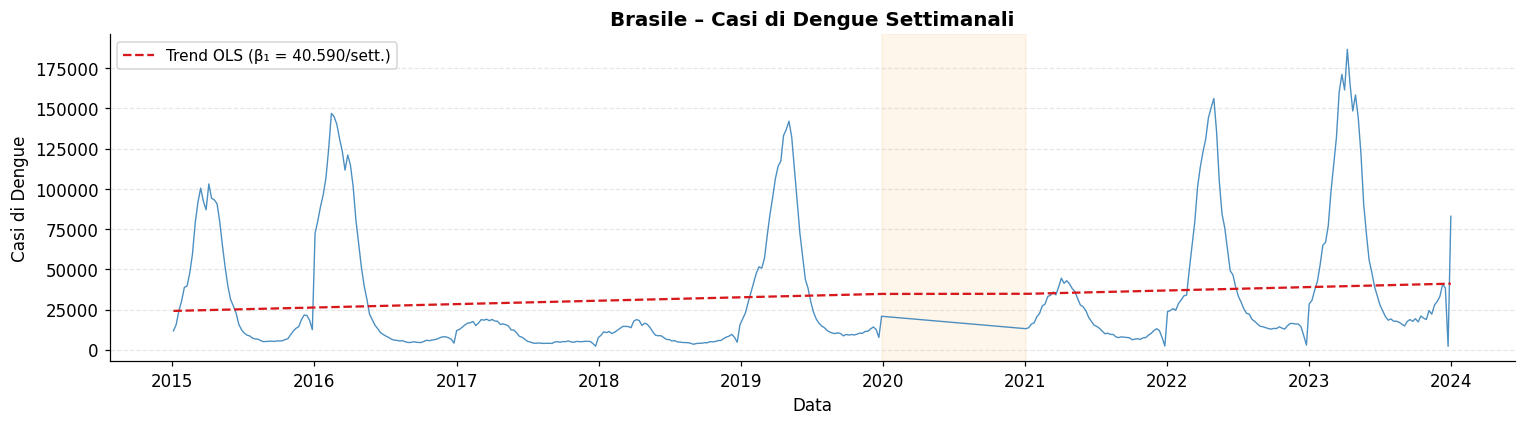

In [22]:
# Serie storica completa (scala originale)
ut.plot_time_series(
    ts=df_bra_full["dengue_total"],
    dates=df_bra_full["date"],
    title="Brasile – Casi di Dengue Settimanali",
    ylabel="Casi di Dengue",
    highlight_gaps=True,
)

La visualizzazione della serie storica mostra come l'anno 2020 sia mancante (verosimilmente per interruzione della sorveglianza durante la pandemia COVID-19). Dobbiamo quindi decidere come imputare i dati mancanti per le serie storiche. Le possibilità sono due:

- **Escludere l'anno 2020 dalla successiva analisi predittiva**. Questa scelta ha le seguenti conseguenze sulla successiva fase di model selection: aplicare la Expanding Window CV (analogo per serie storiche del ciclo più interno della nested K-Fold CV)esclusivamente all'interno del blocco denso 2015-2019 e utilizzare il futuro post-2020 per la fase di test:
     - Fold 1: Train (2015-2016) → Validation 2017
     - Fold 2: Train (2015-2017) → Validation 2018
     - Fold 3: Train (2015-2018) → Validation 2019

- **Imputazione stagionale dell'anno 2020**: tale scelta consiste nel riempire la settimana 1 del 2020 con la media dei casi della settimana 1 degli anni passati (es. 2015-2019), e così via per tutte e 52 le settimane. In pandas questo si fa connettendosi alle medie del `groupby(df.index.isocalendar().week)`. Questa scelta ha le seguenti conseguenze sulla successiva fase di model selection:
    - Fold prima del 2020 (es. Train 2015-2017 → Val 2018): Il 2020 è nel futuro. Non esiste nel dataset di questo fold, quindi non c'è bisogno di compiere alcuna imputazione.
    - Fold in cui il 2020 cade nel Validation Set (es. Train 2015-2019 → Val 2020). Il validation set è completamente imputato, misurare l'errore di un modello rispetto a un dato inventato è statisticamente inutile e fuorviante. Non si può usare il 2020 come Validation Set. Di conseguenza questo fold va scartato.
    - Fold in cui il 2020 cade nel Training Set (es. Train 2015-2020 → Val 2021). In questo caso si (A) prende il blocco di train, (B) si calcola la media settimanale dei casi di Dengue usando esclusivamente gli anni 2015-2019 presenti in questa finestra di Train, (C) si riempie il 2020 con queste medie, (D) si addestra il modello sulla finestra 2015-2020 (che ora è una serie continua e stazionaria grazie all'imputazione) e (E) si valida il modello sul validation Set (2021), che contiene dati reali.

Pare evidente dalla discussione appena compiuta che la scelta più efficace e meno problematica sia la prima. Decidiamo quindi di **Escludere l'anno 2020 dalla successiva analisi predittiva**. Ricordiamo che il ciclo più interno permette di calcolare, per ogni tupla di iperparametri, l'errore medio di validazione sui K fold e scegliere la tupla di iperparametri che definisce il modello migliore (es. il modello con l'RMSE o MAE più basso). Per la fase di test sopra menzionata, si prende il modello migliore generato dal ciclo interno, lo si ri-addestra su tutto il blocco 2015-2019 e lo testa sul blocco 2021-2023.

Nota pratica: Dato che i modelli ARIMA hanno bisogno dei valori immediatamente precedenti per prevedere il futuro, per prevedere gennaio 2021 dovrai fornire all'algoritmo le prime settimane del 2021 come "condizioni iniziali" (o trattare il 2021-2023 come una nuova serie storica a sé stante su cui fare inferenza con i pesi appresi in precedenza).

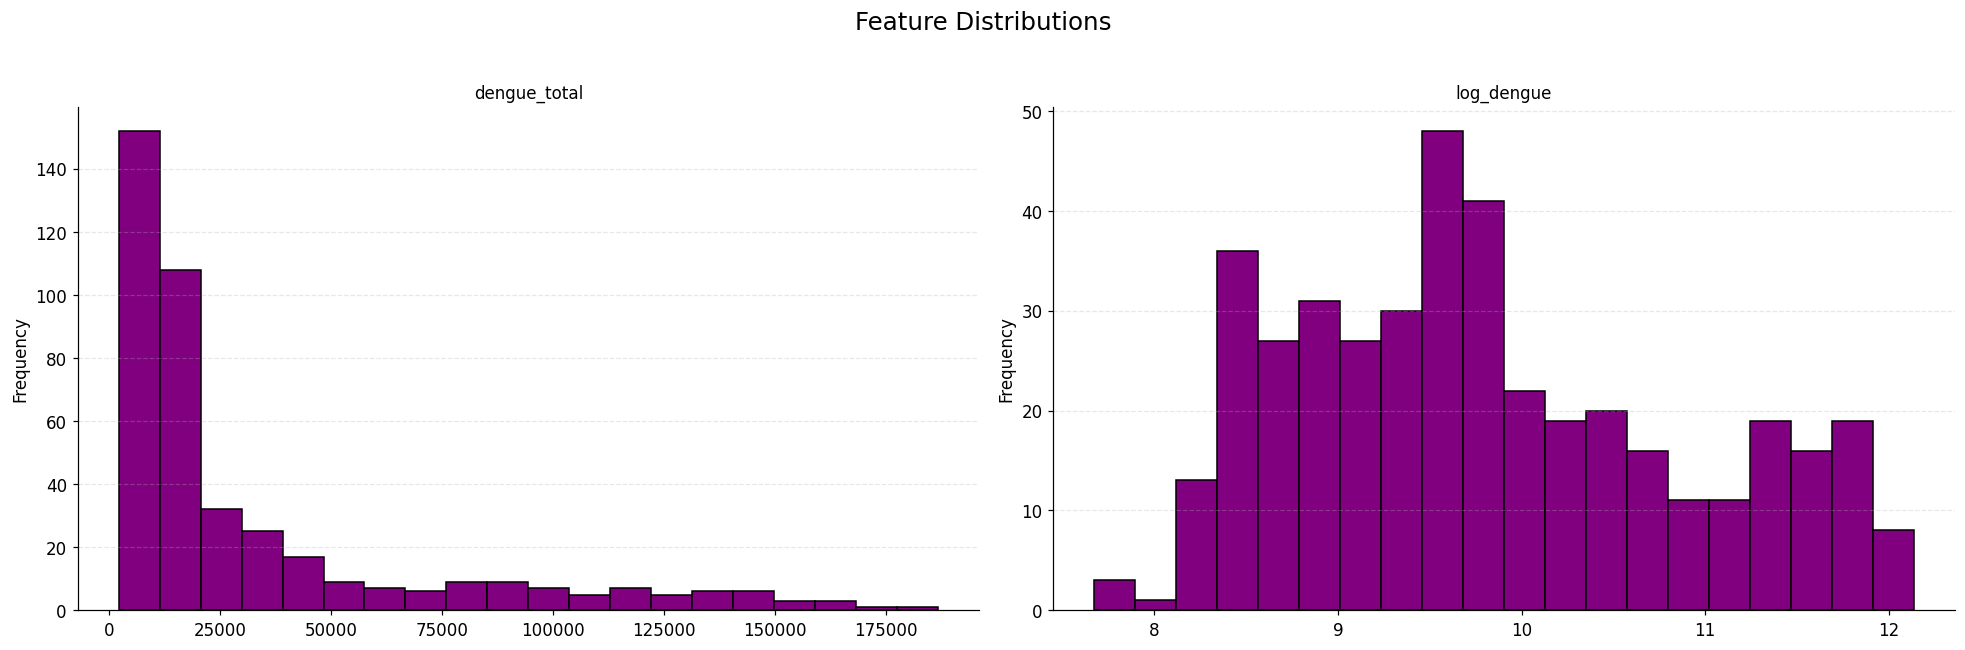

In [23]:
# Log-trasformazione (utile se 'dengue_total' molto asimmetrico)
df_bra_full['log_dengue'] = np.log1p(df_bra_full['dengue_total'])

features = ['dengue_total', 'log_dengue']
ut.plot_histograms(df_bra_full, features)

Da i risultati visualizzabili nel plot precedent (primo sotto-plot, a sinistra), è possibile notare come la variabile `dengue_total` segua una distribuzione fortemente asimmetrica con lunga coda a destra (tipica dei conteggi epidemiologici), ben approssimabile da una distribuzione log-normale. La trasformazione $y'_t = \log(y_t + 1)$ produce una distribuzione più simmetrica e approssimativamente normale (secondo sotto-plot, a destra), soddisfacendo le assunzioni dei modelli lineari che richiedono target distribuito secondo distribuzione normale. La costante $+1$ è necessaria per gestire i valori nulli (in questo dataset assenti, ma comune in altri Paesi).

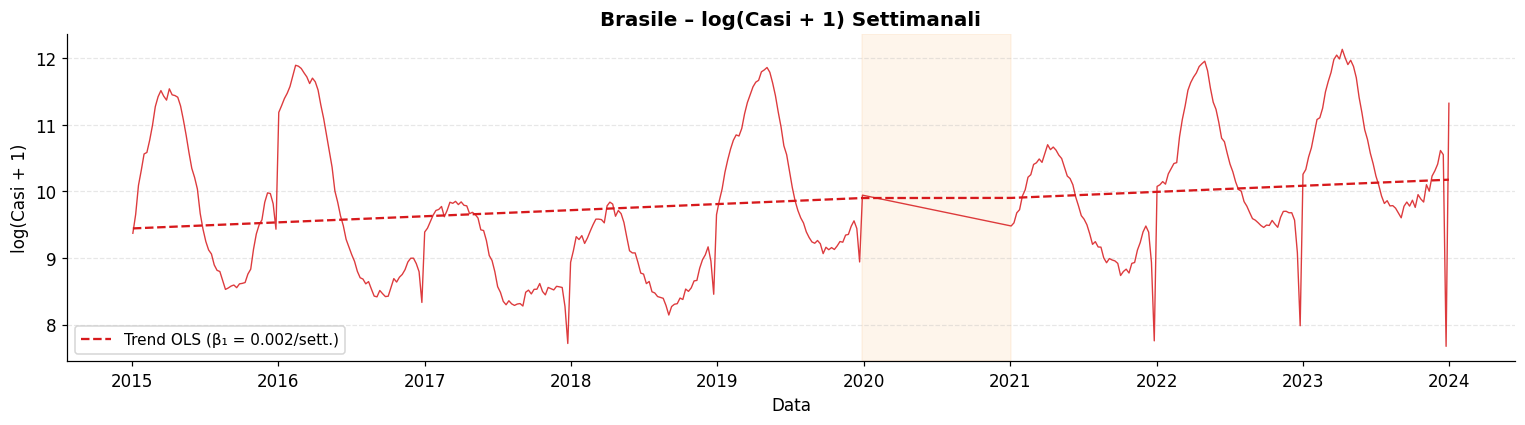

In [24]:
# Serie in scala logaritmica
ut.plot_time_series(
    ts=df_bra_full["log_dengue"],
    dates=df_bra_full["date"],
    title="Brasile – log(Casi + 1) Settimanali",
    ylabel="log(Casi + 1)",
    color=ut.PALETTE["red"],
    highlight_gaps=True,
)

### 2.2 Analisi del profilo stagionale 

Il profilo stagionale caratterizza il pattern *intra-annuale* della serie, aggregando le osservazioni per settimana attraverso gli anni. La **heatmap Anno × Settimana** rivela la struttura bidimensionale del segnale epidemiologico, mentre il **profilo stagionale settimanale** mostra la mediana e il range interquantile del profilo annuale.

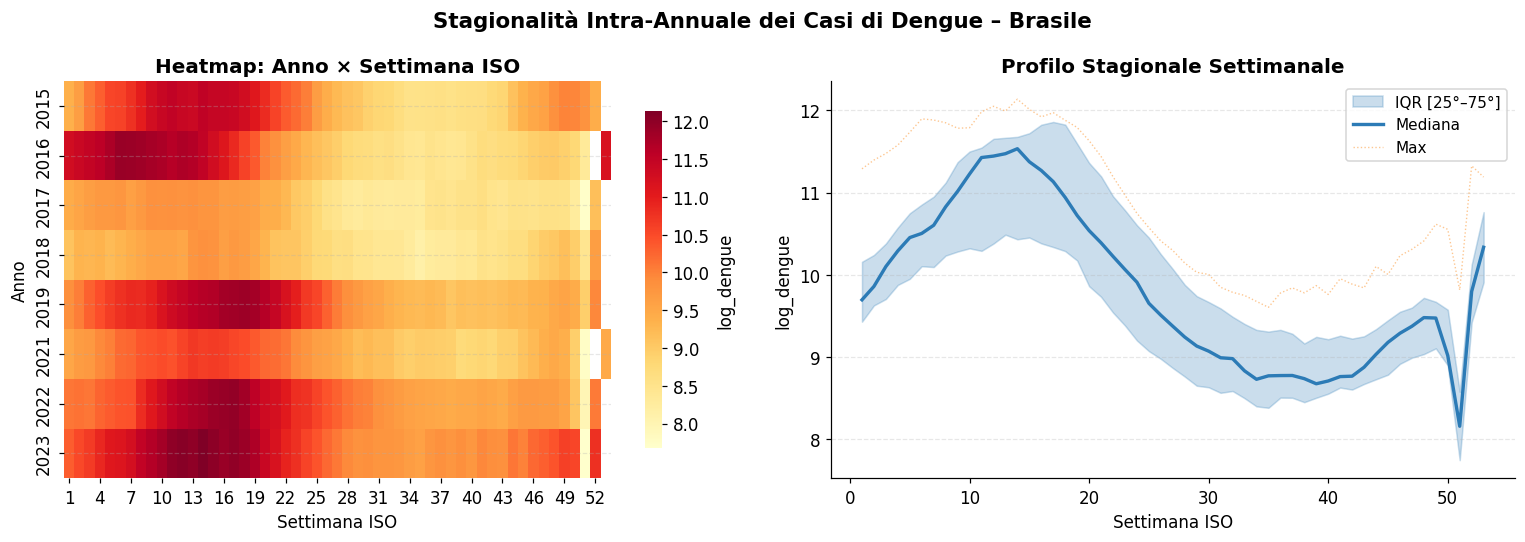

In [25]:
# Profilo stagionale (periodo moderno, dal 2010 in poi)
df_bra_mod = df_bra_full[df_bra_full["Year"] >= 2010].copy()
ut.plot_seasonal_profile(df_bra_mod, col="log_dengue", country="Brasile")

Notiamo che la nostra serie temporale è fortemente stagionale, ogni anno infatti abbiamo picco intorno alla 15-esima settimana, seguito da un decadimento fino ad un minimo intorno alla 35-esima settimana. Oltre alla stagionalità, possiamo operare la decomposizione **STL** (Seasonal-Trend decomposition) per separare la serie nelle seguenti tre componenti (additive in scala logaritmica):

$$y_t = \Tau_t + S_t + R_t$$

dove $\Tau_t$ è il trend, $S_t$ è la componente stagionale periodica, e $R_t$ è il residuo.

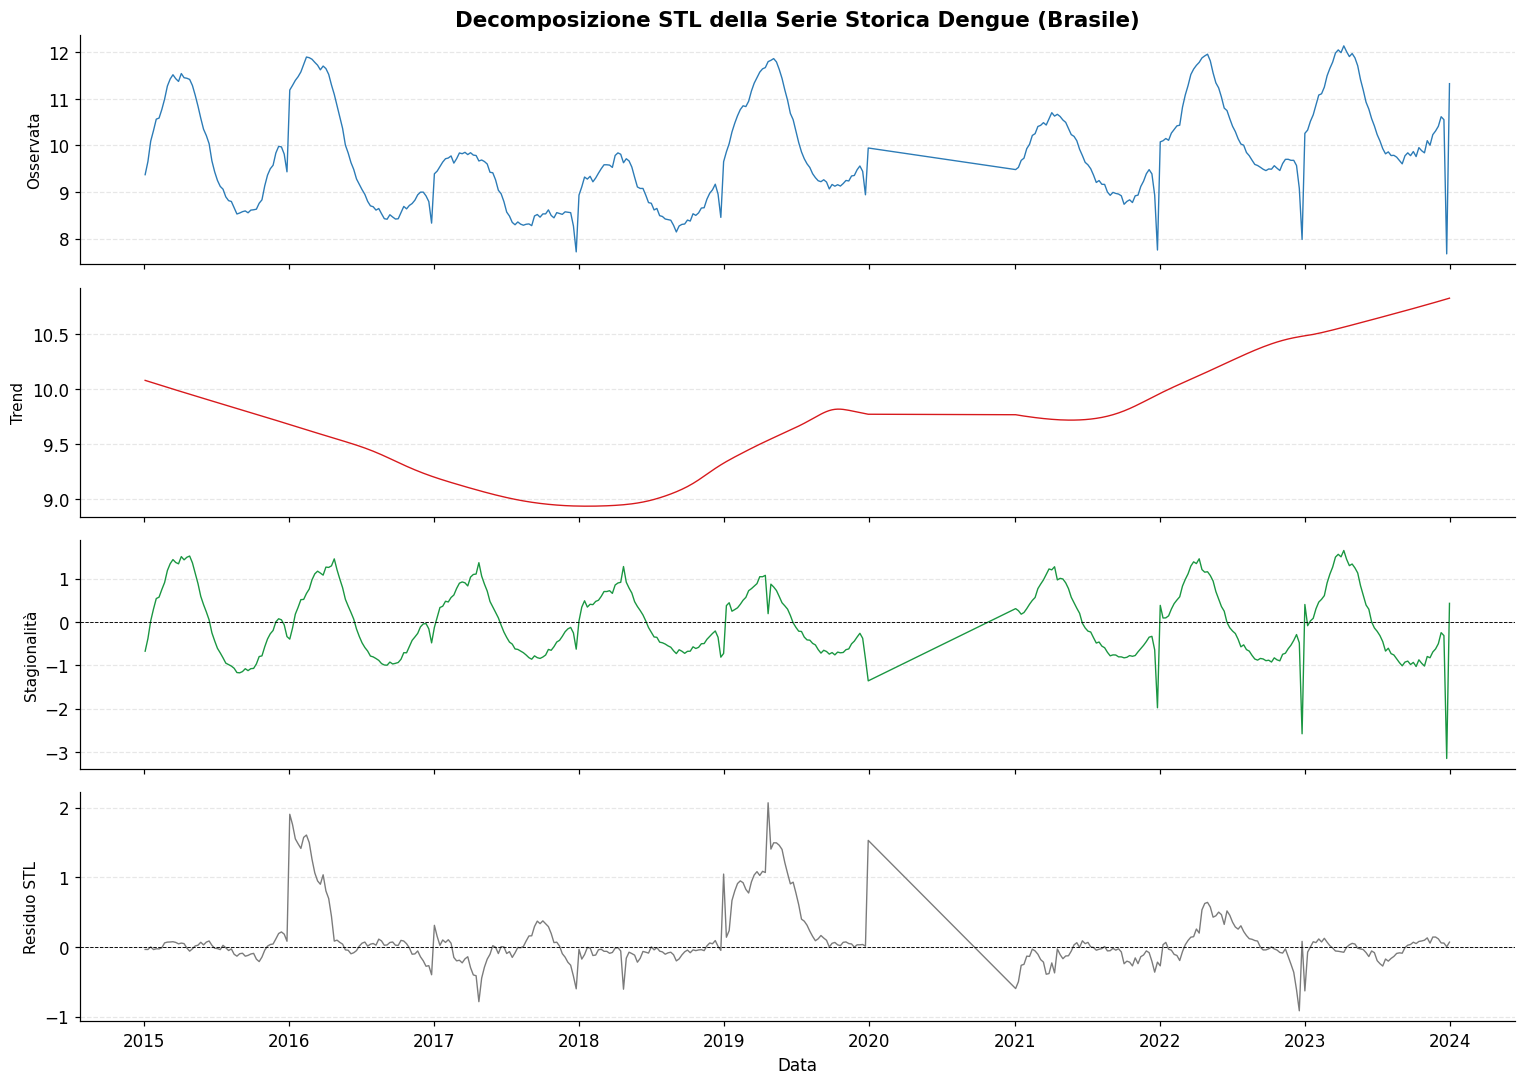

In [26]:
# Decomposizione STL – periodo moderno
ut.plot_stl_decomposition(
    ts=df_bra_mod["log_dengue"].reset_index(drop=True),
    dates=df_bra_mod["date"].reset_index(drop=True),
    period=52,
    country="Brasile",
)

Notiamo che la nostra serie ha un trend marcato. Per poter applicare un modello ARMA(p,q) dobbiamo verificare la stazionarietà della serie stessa. Procediamo quindi con i test di stazionarietà sulla serie storica. Un processo $\{Y_t\}$ è stazionario in senso debole se tutte le variabili aleatorie sono caratterizzate da stesso valore atteso e covarianza che dipende solo dal lag tra le due variabili e non dagli istanti di tempo specifici:

$$E[Y_t] = \mu \quad, \quad \text{Cov}(Y_t, Y_{t+h}) = \gamma(h) \quad \forall t \in \mathbb{N} \quad .$$

Per testarla utilizziamo due test complementari:

**ADF** (Augmented Dickey-Fuller, Dickey & Fuller, 1979):
- $H_0$: $\gamma = 0$ (radice unitaria → non stazionaria)
- Si rifiuta $H_0$ se la statistica ADF è sufficientemente negativa ($p < 0.05$)

**KPSS** (Kwiatkowski *et al.*, 1992):
- $H_0$: la serie è stazionaria (o trend-stazionaria)
- Si rifiuta $H_0$ se la statistica LM è sufficientemente grande ($p < 0.05$)

In [27]:
# Test su log(dengue+1) – serie del training set
df_stat = df_bra_full[df_bra_full["Year"].between(2015, 2023)].copy()
stat_results = ut.run_stationarity_tests(df_stat["log_dengue"],
                                          name="log(dengue+1)")

# Stesso test sulla serie differenziata una volta (d=1)
d1 = df_stat["log_dengue"].diff().dropna()
stat_d1 = ut.run_stationarity_tests(d1, name="Δlog(dengue+1)")

pd.concat([stat_results, stat_d1], ignore_index=True).set_index(["Serie", "Test"])

H₀  Statistica  p-value  \
Serie          Test                                                           
log(dengue+1)  ADF   Radice unitaria (non stazionaria)     -6.2360   0.0000   
               KPSS                  Serie stazionaria      0.3569   0.0957   
Δlog(dengue+1) ADF   Radice unitaria (non stazionaria)     -6.3934   0.0000   
               KPSS                  Serie stazionaria      0.0285   0.1000   

                     Lag   VC 5%               Conclusione  
Serie          Test                                         
log(dengue+1)  ADF     9 -2.8687  Stazionaria (rifiuto H₀)  
               KPSS   12  0.4630               Stazionaria  
Δlog(dengue+1) ADF    18 -2.8688  Stazionaria (rifiuto H₀)  
               KPSS    0  0.4630               Stazionaria

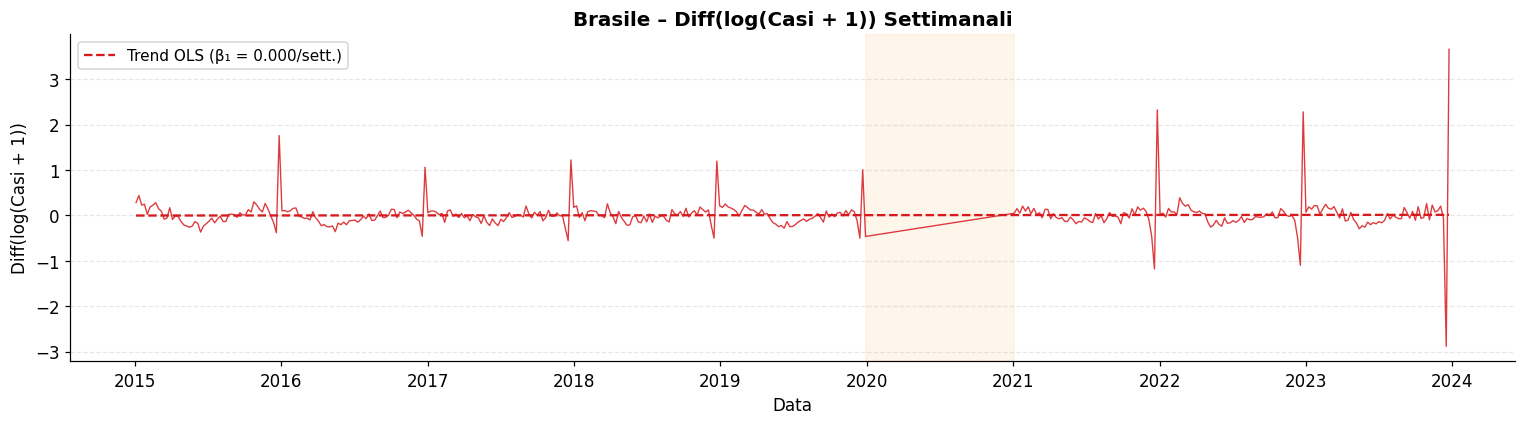

In [28]:
# Serie in scala logaritmica
ut.plot_time_series(
    ts=d1,
    dates=df_stat["date"][:-1],
    title="Brasile – Diff(log(Casi + 1)) Settimanali",
    ylabel="Diff(log(Casi + 1))",
    color=ut.PALETTE["red"],
    highlight_gaps=True,
)

Dall'analisi esplorativa svolta fin ora emerge che la serie temporale presenta trend marcato e una forte componente stagionale. Poiché i modelli della famiglia ARMA richiedono rigorosamente l'assunzione di stazionarietà abbiamo deciso di svolgere i test di stazionarietà sia sulla serie originale sia sulla sua derivata prima. I risulatti mostrano che, sebbene entrambe le serie siano stazionarie in senso stocastico, la serie originale presenta comunque un trend mentre la sua derivata prima è a media nulla.

Si tenga presente quindi che se scegliessimo di usare la serie storica originale, la presenza del trend e dell forti fluttuazioni locali **all'interno delle singole finestre di addestramento della Nested Walk-Forward Cross-Validation** potrebbero violare, a livello locale, l'assunzione di stazionarietà verificata a livello globale. 

Per questo modtivo è possibile prevedere che il modello successivamente indicato dai cicli più interni della Nested Walk-Forward Cross-Validation possa essere una ARIMA(p,d,q) o un SARIMA(p,d,q)(P,D,Q)[h] con $d=1$.

### 2.3 Funzioni di Autocorrelazione (ACF e PACF)

Le funzioni ACF e PACF guidano la selezione degli ordini $p$ (AR) e $q$ (MA) dell'ARIMA, e dei termini stagionali $P$, $Q$ dell'eventuale SARIMA. In particolare: 

- La **funzione di autocorrelazione** (ACF) misura la correlazione lineare tra $y_t$ e $y_{t-h}$ ($\hat{\gamma}(h)$ è l'Autocovarianza Campionaria al lag $h$). 

- La **funzione di autocorrelazione parziale** (PACF) misura la correlazione tra $y_t$ e $y_{t-h}$ dopo aver rimosso l'effetto dei lag intermedi ($\hat{\rho}(h)$ è l'Autocorrelazione Campionaria al lag h).

$$\hat{\rho}(h) = \frac{\hat{\gamma}(h)}{\hat{\gamma}(0)}, \qquad
\hat{\gamma}(h) = \frac{1}{n} \sum_{t=h+1}^{n} (y_t - \bar{y})(y_{t-h} - \bar{y})$$

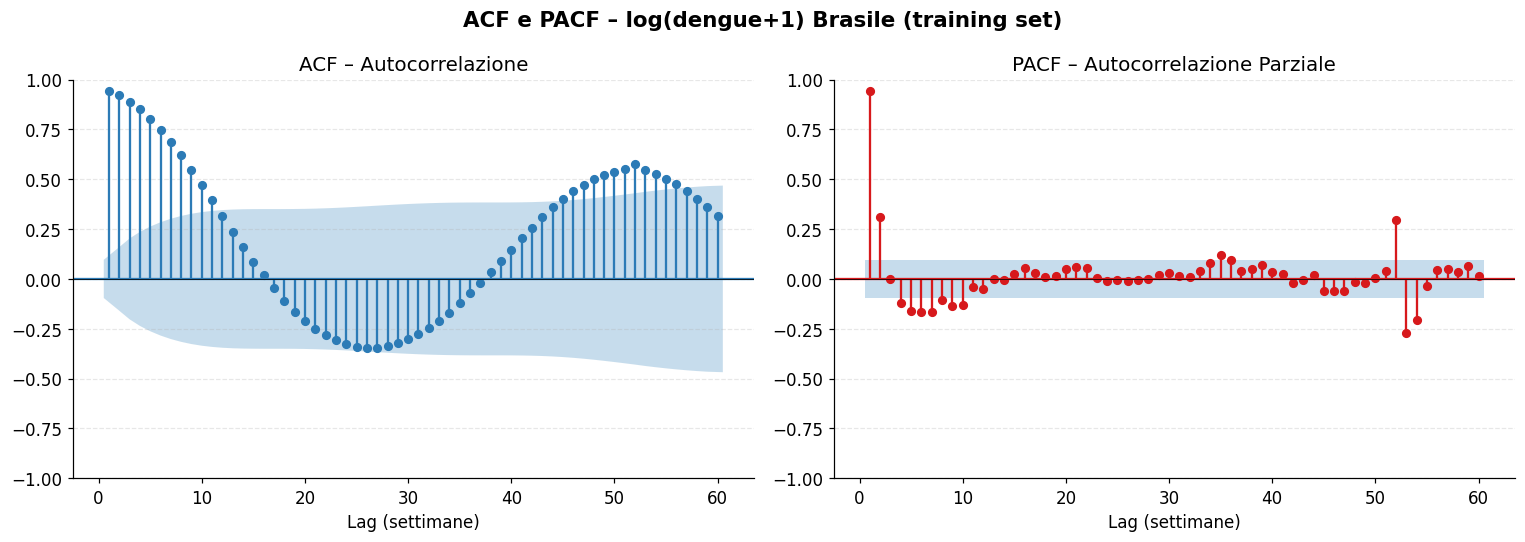

In [29]:
# ACF e PACF della serie log(dengue+1) – training set
ut.plot_acf_pacf(
    df_stat["log_dengue"],
    lags=60,
    title="ACF e PACF – log(dengue+1) Brasile (training set)",
)

Nelle curve ottenute osserviamo una ACF con decadimento periodico e una PACF che presenta picchi significativi a lag 0, lag 1 e lag 52 (quest'ultima mostra un'autocorrelazione significativa della serie con la serie shiftata di un anno). In generale, queste curve vanno lette secondo la seguente tabella:

| Pattern ACF | Pattern PACF | Modello suggerito |
|:------------|:-------------|:------------------|
| Decadimento geometrico | Cut-off al lag $p$ | AR($p$) |
| Cut-off al lag $q$ | Decadimento geometrico | MA($q$) |
| Decadimento (oscillatorio) | Decadimento (oscillatorio) | ARMA($p$,$q$) |
| Spike ai multipli di 52 | Spike ai multipli di 52 | Componente stagionale |

Le bande di confidenza al 95% sono $\pm 1.96 / \sqrt{n}$.

La presenza di una forte componente stagionale è confermata anche in questo frangente, per avere un'indicazione chiara di quali possano essere i parametri $p$ e $q$ **rimuoviamo la componente stagionale e ricalcoliamo le curve ACF e PACF**.

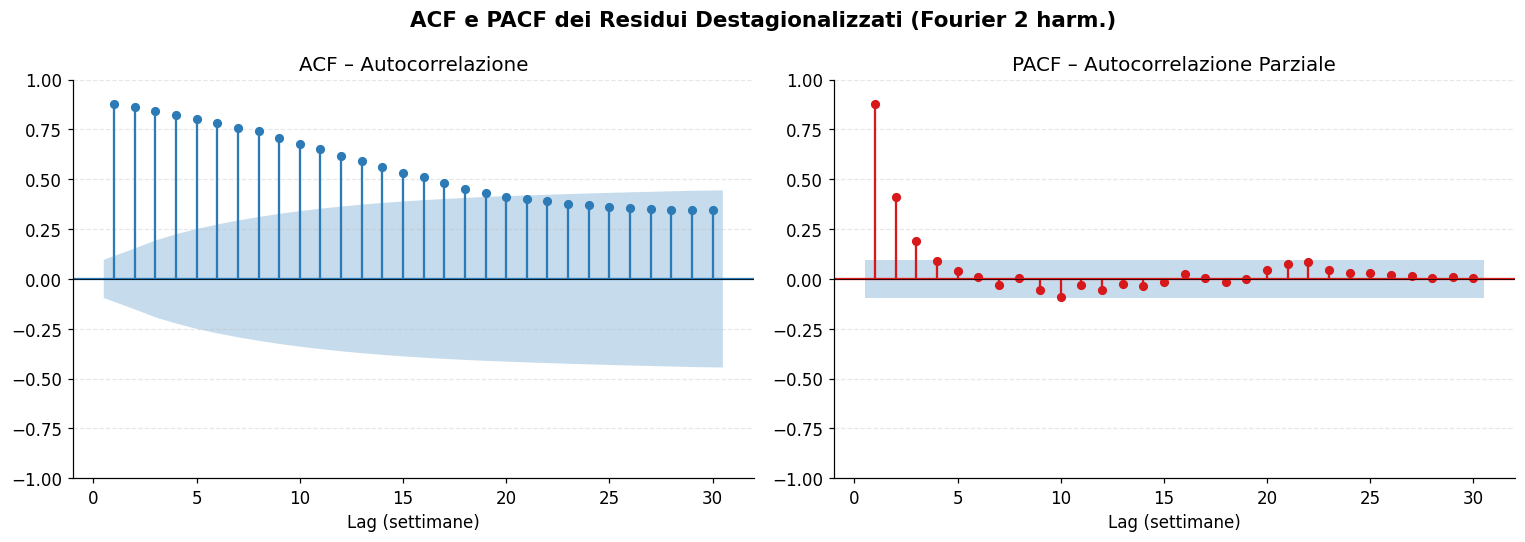

In [30]:
# ACF e PACF dei residui dopo rimozione della stagionalità Fourier (2 armoniche)
# Utile per identificare l'ordine ARMA sui residui destagionalizzati

# Rimozione della stagionalità con OLS (fourier 2 armoniche)
t_arr = (df_stat["date"] - df_stat["date"].iloc[0]).dt.days.values / 7.0
from sklearn.linear_model import LinearRegression
X_fou = ut.make_fourier_features(t_arr, n_harmonics=2).values
ols_seas = LinearRegression().fit(X_fou, df_stat["log_dengue"].values)
residuals_deseas = df_stat["log_dengue"].values - ols_seas.predict(X_fou)
res_series = pd.Series(residuals_deseas, index=df_stat.index)

ut.plot_acf_pacf(
    res_series,
    lags=30,
    title="ACF e PACF dei Residui Destagionalizzati (Fourier 2 harm.)",
)

Alla luce dei risultati ottenuti, se dovessimo allenare un modello di forcasting sull'intera serie temporale sceglieremmo un ARIMA(p,d,q) o un SARIMA(p,d,q)(P,D,Q)[h] con i seguenti parametri:

- p=3: Visto in modo chiaro nella serie destagionalizzata.
- d=1: Visto cel la derivata prima della serie è stazionaria e non presenta trend
- q=0: Perché il decadimento dell'ACF e il taglio del PACF puntano a un modello puro AR per la parte stocastica.

- P=1: Per via dello spike positivo a lag 52.
- D=0: Perchè la struttura del ciclo annuale della Dengue è sostanzialmente stabile e ripetitiva nel tempo (non c'è bisogno di una derivazione per stabilizzare la varianza stagionale).
- Q=0: In assenza di spike isolati a lag 52 solo sull'ACF.
- h=52: per la stagionalità annuale della serie storica.

Tuttavia, nel contesto di Nested Walk-Forward Cross-Validation, i parametri potrebbero variare, calcolando che i dati di training (interni ed esterni) saranno sempre un sottoinsieme della totalità di dati disponibili.

---

## 4. Nested Walk-Forward Cross-Validation per ARIMA/SARIMA

La classica Nested $k$-fold CV rimescola casualmente le osservazioni. Nelle serie storiche, questo approccio distrugge la struttura temporale e causa **data leakage** (l'inserimento di osservazioni future nel training set per prevedere il passato).

Per mantenere l'ordine cronologico e testare i modelli in condizioni realistiche, si utilizza la **Nested Expanding Window CV** (o *Nested Walk-Forward Validation*). Fissato un fold $i$, la suddivisione matematica è definita come:

$$
\text{Fold } i: \quad
  \underbrace{y_1, \ldots, y_{n_i}}_{\text{training}} \;,\;
  \underbrace{y_{n_i+1}, \ldots, y_{n_i+h}}_{\text{validazione}}
  \quad \text{con } n_i < n_j \;\text{se}\; i < j
$$

Nel nostro caso studio, a causa dell'interruzione della sorveglianza nel 2020, individuiamo nel triennio 2017-2019 i dati utili a formare i fold interni e usiamo i dati del triennio 2021-2023 per formare i fold esterni:

**1. Inner Folds (Model Selection sul Training Set 2015-2019)**
Utilizzati per scegliere la tupla di iperparametri ottimi, garantendo che il modello non veda il futuro:
* **Fold 1:** Train (2015-2016) → Validation (2017)
* **Fold 2:** Train (2015-2017) → Validation (2018)
* **Fold 3:** Train (2015-2018) → Validation (2019)

La griglia di ricerca per ARIMA copre:

- $p \in \{0, 1, 2, 3\}$ — termine autoregressivo
- $d \in \{0, 1\}$ — ordine di differenziazione (guidato dai test di stazionarietà)
- $q \in \{0, 1, 2, 3\}$ — termine a media mobile

Totale: $4 \times 2 \times 4 = 32$ combinazioni.

Il criterio di selezione nell'inner loop è il **RMSE medio** sui fold interni
(criterio predittivo, non informativo come AIC/BIC).

**2. Outer Folds (Model Evaluation sul Test Set 2021-2023)**
Simulano il rilascio operativo del modello anno per anno. Il modello viene ri-alimentato con i dati più recenti per aggiornare le condizioni iniziali (memoria a breve termine), pur mantenendo l'esclusione (tramite `NaN`) del gap pandemico del 2020:
* **Outer Fold 1 (Contesto 2021):**
  * *Fit:* `y_train` + `NaN(52)` + `y_test[settimane 0:4]` (condizioni iniziali 2021)
  * *Forecast:* `y_test[settimane 4:52]` (restante 2021)
* **Outer Fold 2 (Contesto 2022):**
  * *Fit:* `y_train` + `NaN(52)` + `y_test[settimane 0:56]` (2021 + condizioni iniziali 2022)
  * *Forecast:* `y_test[settimane 56:104]` (restante 2022)
* **Outer Fold 3 (Contesto 2023):**
  * *Fit:* `y_train` + `NaN(52)` + `y_test[settimane 0:108]` (2021 + 2022 + condizioni iniziali 2023)
  * *Forecast:* `y_test[settimane 108:156]` (restante 2023)

Training: 261 osservazioni  (2015-01-04 – 2019-12-29)
Test    : 157 osservazioni  (2021-01-03 – 2023-12-31)

Statistiche y_train  (log-scale):
count    261.000
mean       9.583
std        1.059
min        7.715
25%        8.662
50%        9.355
75%       10.061
max       11.898


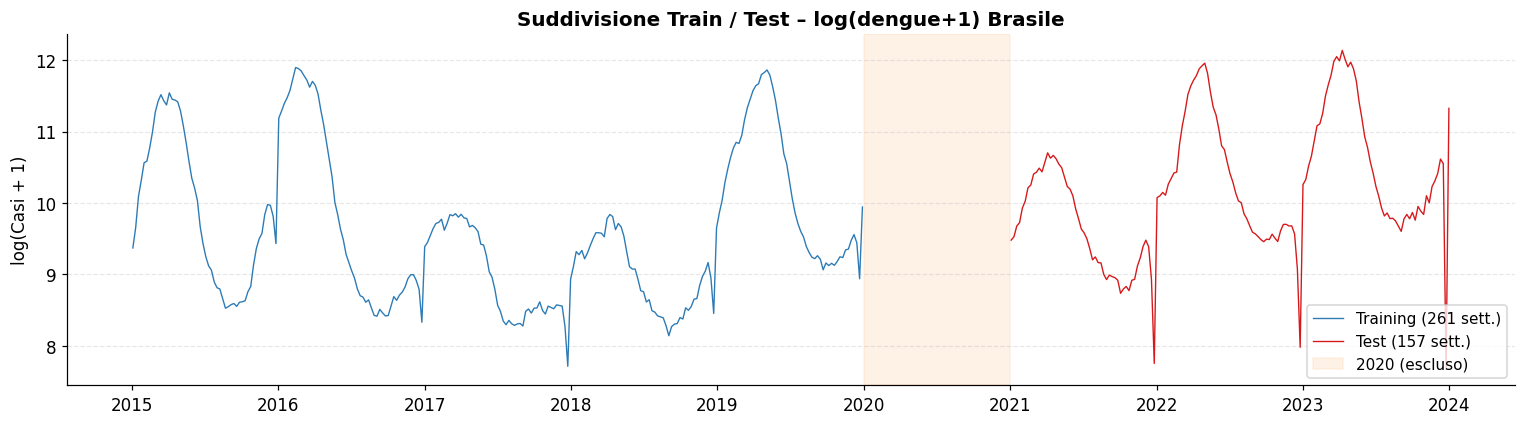

In [31]:
# Suddivisione train / test (esclusione del 2020)
df_train = df_bra_full[df_bra_full["Year"].between(2015, 2019)].copy().reset_index(drop=True)
df_test  = df_bra_full[df_bra_full["Year"] >= 2021].copy().reset_index(drop=True)

print(f"Training: {len(df_train)} osservazioni  "
      f"({df_train['date'].min().date()} – {df_train['date'].max().date()})")
print(f"Test    : {len(df_test)} osservazioni  "
      f"({df_test['date'].min().date()} – {df_test['date'].max().date()})")

# Serie univariata target
y_train = df_train["log_dengue"].values
y_test  = df_test["log_dengue"].values

print(f"\nStatistiche y_train  (log-scale):")
print(pd.Series(y_train).describe().round(3).to_string())

# Visualizzazione split temporale
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_train["date"], y_train, color=ut.PALETTE["blue"],
        linewidth=0.9, label=f"Training ({len(df_train)} sett.)")
ax.plot(df_test["date"], y_test, color=ut.PALETTE["red"],
        linewidth=0.9, label=f"Test ({len(df_test)} sett.)")
ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"),
           alpha=0.15, color=ut.PALETTE["orange"], label="2020 (escluso)")
ax.set_title("Suddivisione Train / Test – log(dengue+1) Brasile", fontweight="bold")
ax.set_ylabel("log(Casi + 1)")
ax.legend()
plt.tight_layout()
plt.show()

In [32]:
# ── Griglia di ricerca ARIMA ────────────────────────────────────────────────
P_MAX, D_MAX, Q_MAX = 3, 2, 3

arima_grid = [
    (p, d, q)
    for p in range(0, P_MAX + 1)
    for d in range(0, D_MAX + 1)
    for q in range(0, Q_MAX + 1)
]

results = ut.arima_nested_walk_forward_gap(
    method         = SARIMAX,
    y_train        = y_train,
    y_test         = y_test,
    dates_test     = df_test["date"],
    arima_grid     = arima_grid,
    n_inner        = 3,
    min_inner_train= 52,
    gap_weeks      = 52,
    weeks_per_outer= 52,
    n_init         = 4,    # aumenta se hai ordini AR alti nella grid
    verbose        = False,
)

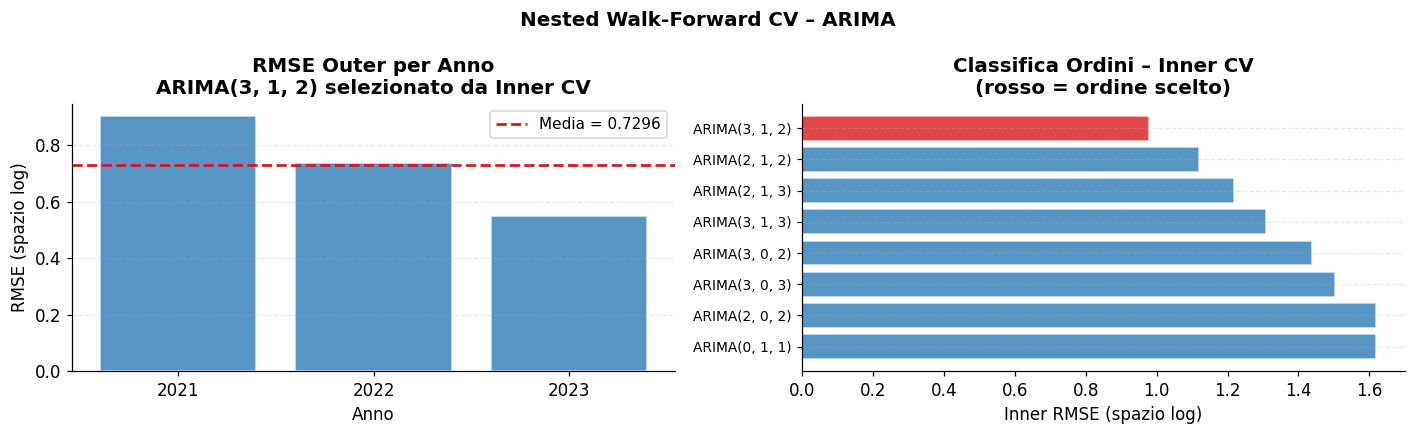

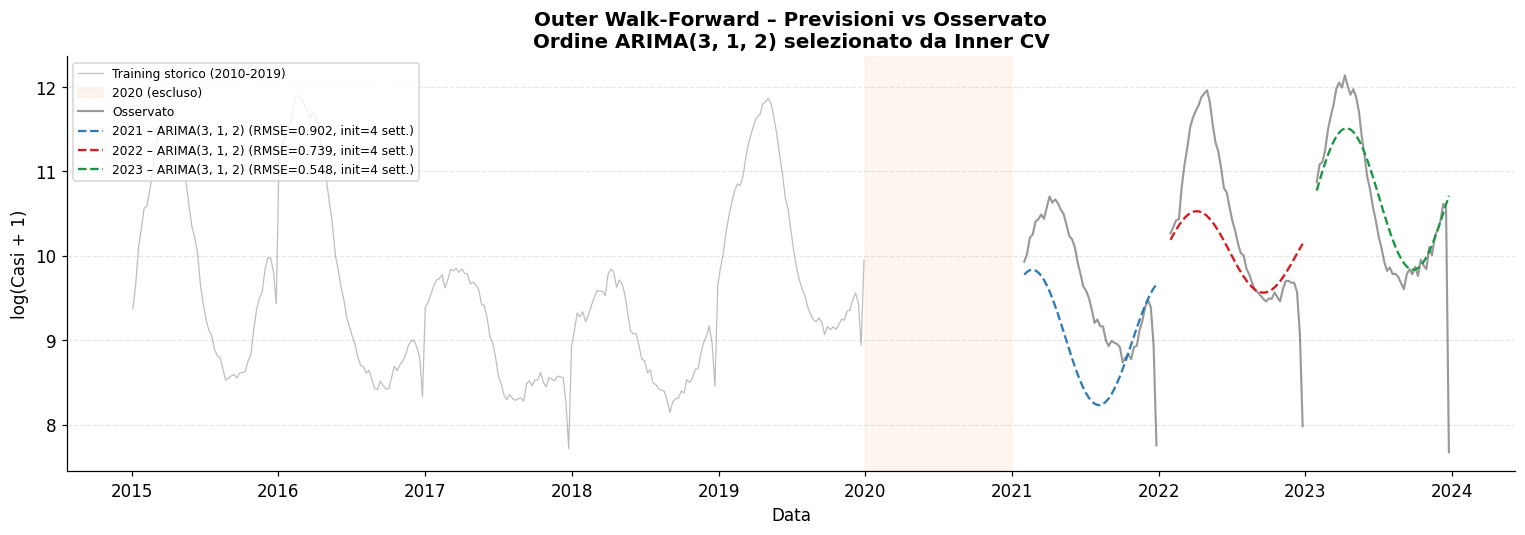

In [33]:
ut.plot_arima_nested_cv_results(results, top_k=8)
ut.plot_arima_outer_predictions(results, df_train, y_train)

In [34]:
# ── Griglia di ricerca SARIMA Ottimizzata ─────────────────────────────────────
# Fissiamo d=1 e limitiamo la ricerca a un intorno ristretto dell'ARIMA(3,1,2)
p_values = [3]       # memoria AR a breve termine
d_values = [1]          # differenziazione fissa (necessaria senza regressori)
q_values = [2]    # memoria MA a breve termine

# Ordini stagionali (tenerli bassi a 0 o 1, m=52 è computazionalmente pesante)
P_max, D_max, Q_max = 1, 1, 1
m = 52 # Stagionalità annuale in settimane

sarima_grid = [
    ((p, d, q), (P, D, Q, m))
    for p in p_values
    for d in d_values
    for q in q_values
    for P in range(0, P_max + 1)
    for D in range(0, D_max + 1)
    for Q in range(0, Q_max + 1)
]

results_2 = ut.arima_nested_walk_forward_gap(
    method         = SARIMAX,
    y_train        = y_train,
    y_test         = y_test,
    dates_test     = df_test["date"],
    arima_grid     = sarima_grid, # <--- Passa la nuova griglia
    n_inner        = 3,
    min_inner_train= 52,
    gap_weeks      = 52,
    weeks_per_outer= 52,
    n_init         = 4,
    verbose        = True,
)

print(f"Numero totale di modelli nella griglia: {len(sarima_grid)}")

  INNER CV — selezione ordine su y_train
  Grid: 8 ordini  |  Inner folds: 3
  ARIMA(3, 1, 2)x(0, 0, 0, 52)  Inner-RMSE=0.9794
  ARIMA(3, 1, 2)x(0, 0, 1, 52)  Inner-RMSE=1.0630
  ARIMA(3, 1, 2)x(0, 1, 0, 52)  Inner-RMSE=0.9114
  ARIMA(3, 1, 2)x(0, 1, 1, 52)  Inner-RMSE=0.9095
  ARIMA(3, 1, 2)x(1, 0, 0, 52)  Inner-RMSE=0.9623
  ARIMA(3, 1, 2)x(1, 0, 1, 52)  Inner-RMSE=0.5282
  ARIMA(3, 1, 2)x(1, 1, 0, 52)  Inner-RMSE=0.9826
  ARIMA(3, 1, 2)x(1, 1, 1, 52)  Inner-RMSE=0.9095

  → Best order: ARIMA(3, 1, 2)x(1, 0, 1, 52)  (Inner-RMSE=0.5282)

  OUTER Walk-Forward — forecast annuale su y_test
  Condizioni iniziali: 4 settimane per anno
  [Outer fold 1 — 2021]  Contesto=317 sett.  Init=4  Forecast=48 sett.  RMSE=0.9214  MAE=0.8739
  [Outer fold 2 — 2022]  Contesto=369 sett.  Init=4  Forecast=48 sett.  RMSE=1.2393  MAE=1.1700
  [Outer fold 3 — 2023]  Contesto=421 sett.  Init=4  Forecast=48 sett.  RMSE=0.3955  MAE=0.2710

  RMSE medio: 0.8521 ± 0.3480
Numero totale di modelli nella griglia: 8


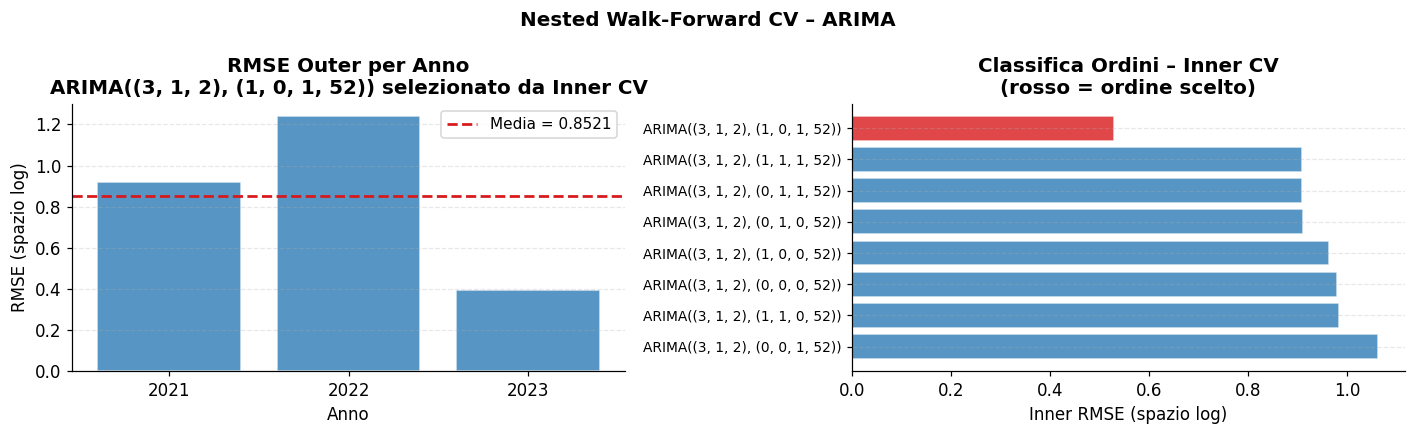

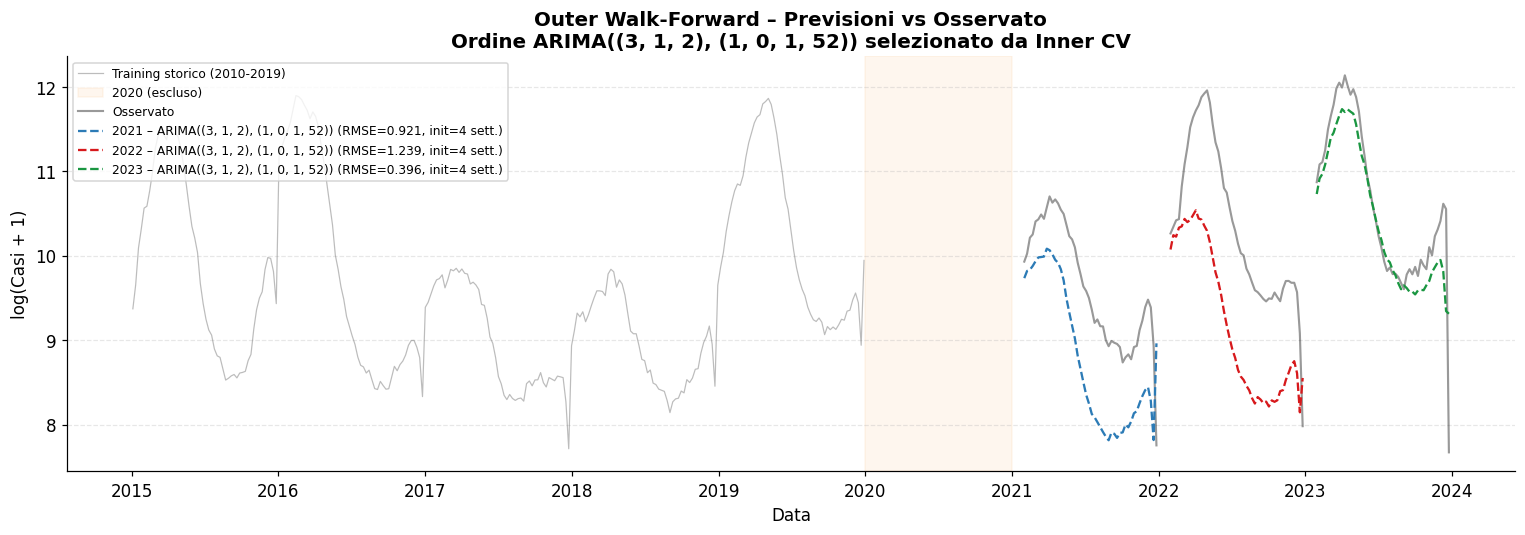

In [35]:
ut.plot_arima_nested_cv_results(results_2, top_k=8)
ut.plot_arima_outer_predictions(results_2, df_train, y_train)